In [1]:
from pathlib import Path
import tifffile as tiff
import matplotlib.pyplot as plt
from segmentations.segmenter import SegmentationModel, SegmentationInstance
from skimage.measure import label, regionprops
from skimage.filters import gaussian
import pandas as pd
import numpy as np
from scipy import ndimage as ndi
from scipy.ndimage import distance_transform_edt

/opt/anaconda3/envs/newsam/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
root = Path('/Users/julian/Documents/General Science/Programming/py/general_analysis/20251130_PatA_RNA_loc/data/RNAscope_tdrd7_nanos/collected_data')
root_dirs = [d for d in root.iterdir() if d.is_dir() and not d.name.startswith('.')]
#
sm_g = SegmentationModel('/Users/julian/Library/Mobile Documents/com~apple~CloudDocs/Documents/General Science/Programming/py/general_analysis/20250722_msam_granule_sizes/gamgee/models/msam/granules/sam_granules_refined_up3_35416497',
                       model_type='vit_l_lm')

for sample_root in root_dirs:
    if sample_root.name != "0x744c6b0f__ctrl__2022-12-16_DMSO_b2_e6c1":
        print("found it")
        continue
    print(sample_root.name)
    tif_name = sample_root / f'{sample_root.name}.lsm'
    # if tif_name.exists():
    #     img = tiff.TiffFile(tif_name)
    # else:
    #     img = tiff.TiffFile(tif_name.name.replace("__exp__", "__ctrl__"))
    img = tiff.imread(sample_root / f'{sample_root.name}.lsm')
    # img = np.max(img, axis=0)
    print(img.shape)

    raw_image_path = sample_root / 'raw'
    raw_image_path.mkdir(exist_ok=True, parents=True)

    # tiff.imwrite(raw_image_path / f'granules.tif', img[0])
    # tiff.imwrite(raw_image_path / f'nanos-rna.tif', img[1])
    # tiff.imwrite(raw_image_path / f'tdrd7-rna.tif', img[2])


    ch_gran = SegmentationInstance(img[0], segmentation_model=sm_g)
    # ch_nos = SegmentationInstance(img[1], segmentation_model=sm_g)
    # ch_tdrd7 = SegmentationInstance(img[2], segmentation_model=sm_g)
    # ch_nuc = SegmentationInstance(img[1], segmentation_model=sm_n)
    # ch_cell = SegmentationInstance(img[1], segmentation_model=sm_c)
    # ch_atag = SegmentationInstance(img[1], segmentation_model=sm_g)

    seg_out_dir = sample_root / 'segmentation'
    seg_out_dir.mkdir(exist_ok=True, parents=True)

    # tiff.imwrite(seg_out_dir / f'nucleus.tif', ch_nuc.segmentation.astype(np.uint16))
    # tiff.imwrite(seg_out_dir / f'nanos_rna.tif', ch_nos.segmentation.astype(np.uint16))
    # tiff.imwrite(seg_out_dir / f'tdrd7a_rna.tif', ch_tdrd7.segmentation.astype(np.uint16))
    tiff.imwrite(seg_out_dir / f'granules.tif', ch_gran.segmentation.astype(np.uint16))
    # tiff.imwrite(seg_out_dir / f'cell.tif', ch_cell.segmentation.astype(np.uint16))
    # tiff.imwrite(seg_out_dir / f'alfatag_speckles.tif', ch_atag.segmentation.astype(np.uint16))

    # if sample_root.is_dir():
    #     csv_path = sample_root / "noise.csv"
    #     if csv_path.exists():
    #         df = pd.read_csv(csv_path)
    #         bbox_xpos = df.loc[0, "BX"]
    #         bbox_ypos = df.loc[0, "BY"],
    #         bbox_width = df.loc[0, "Width"]
    #         bbox_height = df.loc[0, "Height"]
    #     else:
    #         continue
    #     aimg = tiff.imread(sample_root / "raw" / "alfa.tif")
    #     noise_mask = np.zeros(aimg.shape, dtype=bool)
    #     noise_mask[bbox_ypos[0]:bbox_ypos[0]+bbox_height, bbox_xpos:bbox_xpos+bbox_width] = True
    #     tiff.imwrite(sample_root / "segmentation" /"noise.tif", noise_mask.astype(np.uint8))



Using apple MPS device.
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
0x744c6b0f__ctrl__2022-12-16_DMSO_b2_e6c1
(3, 450, 448)


Initialize instance segmentation with decoder: 100%|██████████| 1/1 [00:00<00:00,  2.67it/s]

found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it
found it


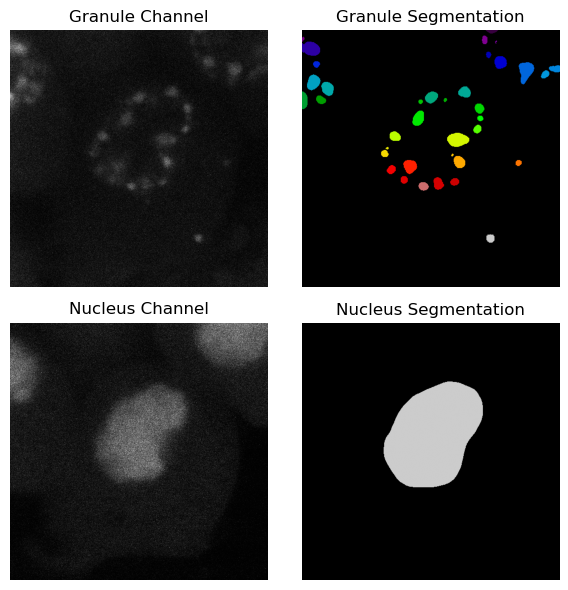

In [60]:
ch_g = SegmentationInstance(tiff.imread(root / 'control_3' / 'raw' / 'granules.tif'), segmentation_model=sm_g)
ch_n = SegmentationInstance(tiff.imread(root / 'control_3' / 'raw' / 'alfa.tif'), segmentation_model=sm_n)


f, a = plt.subplots(2,2, figsize=(6,6))
a[0,0].imshow(ch_g.image, cmap='gray')
a[0,0].axis('off')
a[0,0].set_title('Granule Channel')

a[0,1].imshow(ch_g.segmentation, cmap='nipy_spectral')
a[0,1].set_title('Granule Segmentation')
a[0,1].axis('off')

a[1,0].imshow(ch_n.image, cmap='gray')
a[1,0].axis('off')
a[1,0].set_title('Nucleus Channel')

a[1,1].imshow(ch_n.segmentation, cmap='nipy_spectral')
a[1,1].set_title('Nucleus Segmentation')
a[1,1].axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# def onion(granule_labels, nucleus_labels, granule_id, shell_thickness=2, shell_number=20):
#     granule_mask = granule_labels == granule_id
#
#     for shell_id in range(-3, shell_number):
#         if shell_id > 0:
#             # Gernerate a granule shell
#             dilated = ndi.binary_dilation(granule_mask, iterations=shell_thickness * (shell_id + 1))
#             inner_dilated = ndi.binary_dilation(granule_mask, iterations=shell_thickness * shell_id)
#             shell = np.logical_xor(dilated, inner_dilated)
#
#             # Intersect with nucleus and other granules
#             shell[nucleus_labels > 0] = False
#             shell[granule_labels > 0] = False
#
#             yield shell_id, shell
#         elif shell_id == 0:
#             eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness)
#             shell = np.logical_xor(granule_mask, eroded)
#             yield shell_id, shell
#         else:
#             if shell_id != -3:
#                 eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id))
#                 outer_eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness * (abs(shell_id) + 1))
#                 shell = np.logical_xor(eroded, outer_eroded)
#
#                 # Intersect with nucleus and other granules
#                 shell[nucleus_labels > 0] = False
#
#             else:
#                 shell = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id))
#
#             yield shell_id, shell
#
#
# layer_dict = {}
#
# for shell_id, shell in onion(ak, nk, granule_id=1, shell_thickness=2, shell_number=10):
#     layer_dict[shell_id] = shell


In [83]:
def onion(granule_labels, nucleus_labels, granule_id, shell_thickness=2, shell_number=20, negative_shell_number=3):
    granule_mask = granule_labels == granule_id
    other_granules = (granule_labels > 0) & (granule_labels != granule_id)

    for shell_id in range(-negative_shell_number, shell_number):
        if shell_id > 0:
            dilated = ndi.binary_dilation(granule_mask, iterations=shell_thickness * (shell_id + 1))
            inner_dilated = ndi.binary_dilation(granule_mask, iterations=shell_thickness * shell_id)
            shell = np.logical_xor(dilated, inner_dilated)
            shell[nucleus_labels > 0] = False
            expanded_granules = ndi.binary_dilation(other_granules, iterations=shell_thickness * shell_id)
            shell[expanded_granules] = False
            yield shell_id, shell
        elif shell_id == 0:
            dilated = ndi.binary_dilation(granule_mask, iterations=shell_thickness)
            shell = np.logical_xor(dilated, granule_mask)
            shell[nucleus_labels > 0] = False
            expanded_granules = ndi.binary_dilation(other_granules, iterations=shell_thickness)
            shell[expanded_granules] = False
            yield shell_id, shell
        else:
            if shell_id == -negative_shell_number:
                shell = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id +1))
                shell[nucleus_labels > 0] = False
            else:
                if shell_id == -1:
                    eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id))
                    outer_eroded = granule_mask
                else:
                    eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id))
                    outer_eroded = ndi.binary_erosion(granule_mask, iterations=shell_thickness * abs(shell_id + 1))
                shell = np.logical_xor(eroded, outer_eroded)
                shell[nucleus_labels > 0] = False
            yield shell_id, shell


def garlic(granule_labels, nucleus_labels, granule_id, shell_thickness=2, shell_number=20, negative_shell_number=3, nucleus_safety_distance=True):
    """
    Generate granule shells using a signed distance transform approach.
    :param granule_labels: Label image of granules
    :param nucleus_labels: Label image of nuclei
    :param granule_id: ID of the granule to generate shells for
    :param shell_thickness: Thiccness of each shell in pixels
    :param shell_number: Number of shells to generate outside the granule
    :param negative_shell_number: Number of shells to generate inside the granule
    :param nucleus_safety_distance: if True, add a safety distance around the nucleus to avoid measuring too close to the nucleus
    :return: Yields shell_id and shell mask
    """

    nucleus_labels = nucleus_labels.copy()


    # Get one single granule with granule_id and create a mask
    granule_mask = granule_labels == granule_id

    # Get mask of all other granules
    other_granules = (granule_labels > 0) & (granule_labels != granule_id)

    # Add a safety distance to the nucleus labels
    if nucleus_safety_distance:
        temp_nuclei = nucleus_labels > 0
        safety_distance = ndi.binary_dilation(temp_nuclei, iterations=2)
        nucleus_labels[safety_distance] = 1

    distance_outside = distance_transform_edt(~granule_mask)
    distance_inside = distance_transform_edt(granule_mask)
    signed_distance = np.where(granule_mask, -distance_inside, distance_outside)

    for shell_id in range(-negative_shell_number, shell_number):
        if shell_id > 0:
            lower_bound = shell_thickness * shell_id
            upper_bound = shell_thickness * (shell_id + 1)
            shell = (signed_distance > lower_bound) & (signed_distance <= upper_bound)
            shell[nucleus_labels > 0] = False
            expanded_granules = ndi.binary_dilation(other_granules, iterations=shell_thickness * shell_id)
            shell[expanded_granules] = False
            yield shell_id, shell
        elif shell_id == 0:
            shell = (signed_distance > 0) & (signed_distance <= shell_thickness)
            shell[nucleus_labels > 0] = False
            expanded_granules = ndi.binary_dilation(other_granules, iterations=shell_thickness)
            shell[expanded_granules] = False
            yield shell_id, shell
        else:

            if shell_id == -negative_shell_number:
                shell = signed_distance < (shell_thickness * (shell_id +1))
                # shell[nucleus_labels > 0] = False
            else:
                lower_bound = shell_thickness * shell_id
                upper_bound = shell_thickness * (shell_id + 1)

                shell = (signed_distance >= lower_bound) & (signed_distance < upper_bound)
                # shell[nucleus_labels > 0] = False
            yield shell_id, shell

In [84]:
def verification_image(onion_dict, image_granules, image_alfa, algorithm_name='garlic'):
    """
    Generate a verification image showing the onion/garlic shells overlaid on the granule and ALFA images.
    :param onion_dict:
    :param image_granules:
    :param image_alfa:
    :param algorithm_name:
    :return:
    """
    onion_image = np.zeros_like(image_granules, dtype=float)
    max_shell_id = max(onion_dict.keys())
    min_shell_id = min(onion_dict.keys())
    total_shells = max_shell_id - min_shell_id + 1

    for idx, (shell_id, mask) in enumerate(onion_dict.items()):
        intensity_value = (shell_id - min_shell_id) / total_shells
        onion_image[mask] = (shell_id * 4) + (abs(min_shell_id) * 10)

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].imshow(image_granules, cmap='gray', vmax=np.percentile(image_granules, 99.9))
    ax[0].imshow(onion_image, cmap='twilight_shifted', alpha=np.where(onion_image > 0, 0.7, 0))
    ax[0].set_title('Granule Channel with shells overlay')
    ax[0].axis('off')

    ax[1].imshow(image_alfa, cmap='gray', vmax=np.percentile(image_alfa, 80))
    ax[1].imshow(onion_image, cmap='twilight_shifted', alpha=np.where(onion_image > 0, 0.7, 0))
    ax[1].set_title('ALFA Channel with shells overlay')
    ax[1].axis('off')
    # plt.tight_layout()
    fig.suptitle(f'{algorithm_name} verification image')

    plt.show()

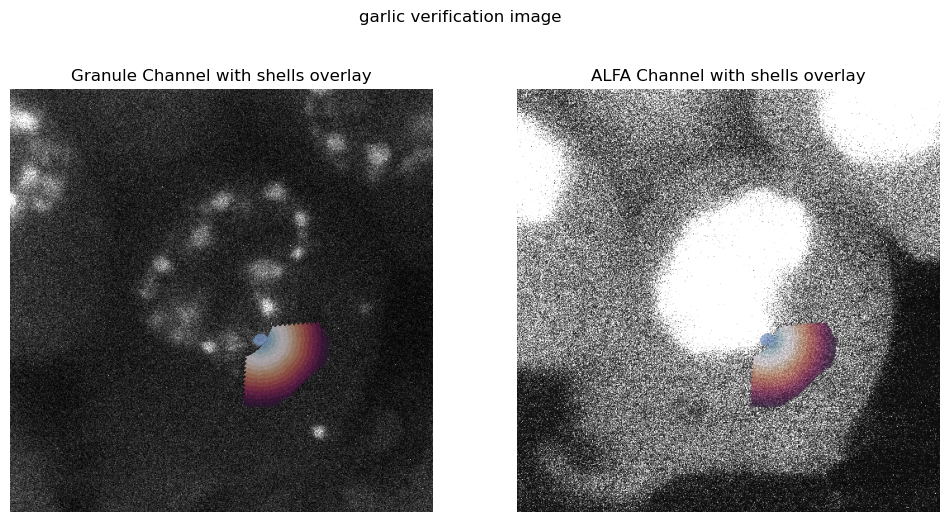

In [85]:
gid = 35
# onion_dicto = dict(onion(ak, nk, granule_id=gid, shell_thickness=5, shell_number=7))
garlic_dicto = dict(garlic(ch_g.segmentation, ch_n.segmentation, granule_id=gid, shell_thickness=5, shell_number=15))

# generate_onion_image(onion_dicto, ch_g.image, algorithm_name='Onion')
verification_image(garlic_dicto, ch_g.image, ch_n.image)

In [ ]:
n=2
plt.imshow(ak,  cmap='inferno')
# plt.imshow(onion_dicto[-1], cmap='Blues', alpha=onion_dicto[-1]/onion_dicto[-1].max())
plt.imshow(garlic_dicto[n], cmap='gray', alpha=garlic_dicto[n]/garlic_dicto[n].max()*0.8)
plt.imshow(garlic_dicto[n-1], cmap='Greens', alpha=garlic_dicto[n-1]/garlic_dicto[n-1].max())

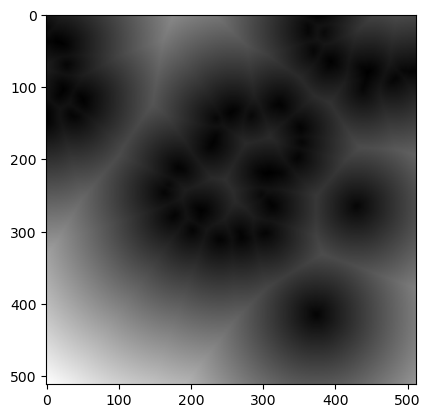